# a04 Example - Bayesian Optimization using Ax over Laser-Fiber Alignment Benchtop: Global Raster Search

# Install External Libraries for Optimizer Implementation

In [1]:
# !python -m pip install ax-platform

# Imports

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from time import sleep

import pyscan as ps
# from pyscan.drivers.thorlabs.thorlabsct1p import ThorlabsCT1P # fiber z-stage
from pyscan.drivers.thorlabs.thorlabspm16_120 import ThorlabsPM16_120 # laser power meter
from demo_notebooks.advanced.laser_fiber_align_measure_functions import raster

## Setup devices

In [3]:
devices = ps.ItemAttribute()


devices.x1 = ps.Agilent33500('USB0::0x0957::0x5707::MY53804557::INSTR', 1)
devices.y1 = ps.Agilent33500('USB0::0x0957::0x5707::MY53804557::INSTR', 2)

devices.x2 = ps.Agilent33500('USB0::0x0957::0x2307::SG50000115::INSTR', 1)
devices.y2 = ps.Agilent33500('USB0::0x0957::0x2307::SG50000115::INSTR', 2)

devices.pm16_120 = ThorlabsPM16_120()

devices.laser = ps.PulseLaser('COM7')

COM7


## Define a measure function

In [4]:
def measure_power(expt):
    d = ps.ItemAttribute()
    d.power_pre_raster = devices.pm16_120.power
    raster(expt.devices)
    d.voltage_x1_raster = devices.x1.voltage
    d.voltage_y1_raster = devices.y1.voltage
    d.voltage_x2_raster = devices.x2.voltage
    d.voltage_y2_raster = devices.y2.voltage
    d.power_raster = devices.pm16_120.power
    return d

# Define live plot

In [5]:
@ps.live_plot
def plot_optim_live(expt):
    global fig, axs
    axs[0].clear()
    axs[0].plot(list(zip(
                  expt.x1_voltage,
                  expt.y1_voltage,
                  expt.x2_voltage,
                  expt.y2_voltage)))
    axs[0].legend(['x1', 'y1', 'x2', 'y2'], loc='center left', bbox_to_anchor=(1, 0.5))
    axs[0].set_xlabel("optimizer step")
    axs[0].set_ylabel("instrument input")
    axs[0].set_title("Instrument Inputs as a Function of Optimizer Step");
    axs[1].clear()
    axs[1].plot(expt.power_raster)
    axs[1].set_xlabel("optimizer step")
    axs[1].set_ylabel("laser power")
    axs[1].set_title("Laser Power as a Function of Optimizer Step");

# Define runinfo

In [6]:
runinfo = ps.RunInfo()
runinfo.measure_function = measure_power

# Implement `AbstractOptimizeScan` with `AxOptimizeScan`

# Instantiate OptimizeScan

In [7]:
z0 = 0.
zf = 100.
v0 = -3.
vf = 3.
vb = (v0, vf)
# x1v0 = -1.3
# x1vf = -1.1
# y1v0 = 1.9
# y1vf = 2.1
# x2v0 = 1.4
# x2vf = 1.6
# y2v0 = 1.1
# y2vf = 1.3

In [8]:
# z_p = ps.AxOptimizeDeviceProperty('ct10', 'position', 0, (z0, zf),
#                                   optimizer_input='z_p_readout',
#                                   initialization_scans=None)
x1 = ps.AxOptimizeDeviceProperty('x1', 'voltage', 0., vb,
                                 optimizer_input='x1_voltage',
                                 type='float',
                                 initialization_scans=[.51])
y1 = ps.AxOptimizeDeviceProperty('y1', 'voltage', 0., vb,
                                 optimizer_input='y1_voltage',
                                 type='float',
                                 initialization_scans=[.94])
x2 = ps.AxOptimizeDeviceProperty('x2', 'voltage', 0., vb,
                                 optimizer_input='x2_voltage',
                                 type='float',
                                 initialization_scans=[-.23])
y2 = ps.AxOptimizeDeviceProperty('y2', 'voltage', 0., vb,
                                 optimizer_input='y2_voltage',
                                 type='float',
                                 initialization_scans=[.15])

In [9]:
runinfo.scan0 = ps.AxOptimizeScan((x1, y1, x2, y2),
                                  'power_raster',
                                  dt=1., n_max=20,
                                  global_improvement_threshold=1e-4,
                                  global_improvement_index_window=5,
                                  global_improvement_start_index=10,
                                  extremum='max')

# Run Experiments

In [10]:
expt = ps.Experiment(runinfo, devices)
expt.start_thread()

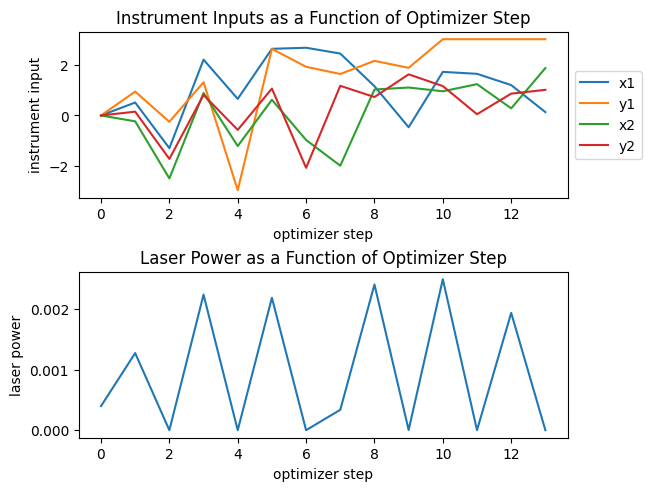

In [11]:
fig, axs = plt.subplots(2, layout='constrained')
try:
    plot_optim_live(expt)
except KeyboardInterrupt:
    expt.stop()

In [12]:
expt.__dict__

{'runinfo': <pyscan.measurement.run_info.RunInfo at 0x1cd6da88ec0>,
 'devices': <itemattribute.item_attribute.ItemAttribute at 0x1cd6d4d5700>,
 'expt_thread': <Thread(Thread-3 (run), stopped daemon 11288)>,
 'iteration': array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
        13., 14.]),
 'x1_voltage': array([ 0.        ,  0.51      , -1.28659987,  2.19644029,  0.65326422,
         2.62188274,  2.66425637,  2.43562933,  1.1511018 , -0.46313531,
         1.71496011,  1.63836029,  1.19563646,  0.13228152,  1.71496011]),
 'y1_voltage': array([ 0.        ,  0.94      , -0.24832463,  1.30722489, -2.93819482,
         2.62180225,  1.91444928,  1.63218536,  2.14784986,  1.87510543,
         3.        ,  3.        ,  3.        ,  3.        ,  3.        ]),
 'x2_voltage': array([ 0.        , -0.23      , -2.47663048,  0.88530688, -1.2026349 ,
         0.61776798, -0.96430302, -1.97516056,  1.02110084,  1.0994958 ,
         0.95173665,  1.23233359,  0.28061747,  1.8649833

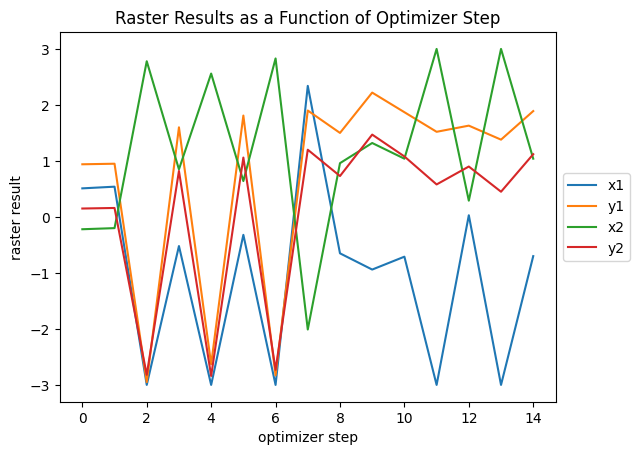

In [18]:
plt.plot(list(zip(
                  expt.voltage_x1_raster,
                  expt.voltage_y1_raster,
                  expt.voltage_x2_raster,
                  expt.voltage_y2_raster)))
plt.legend(['x1', 'y1', 'x2', 'y2'], loc='center left', bbox_to_anchor=(1, 0.5))
plt.xlabel("optimizer step")
plt.ylabel("raster result")
plt.title("Raster Results as a Function of Optimizer Step");

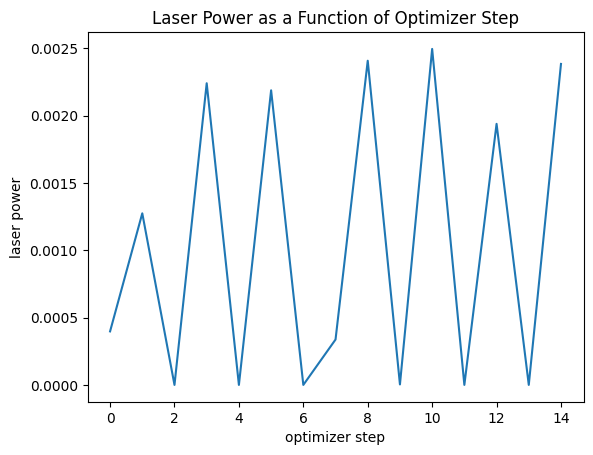

In [17]:
plt.plot(expt.power_raster)
plt.xlabel("optimizer step")
plt.ylabel("laser power")
plt.title("Laser Power as a Function of Optimizer Step");